**Scrapping Data**

Scraping merupakan proses pengambilan datadest. Data diambil dari komentar instagram menggunakan instaloader. Komentar daimbil dari akun @magangmerdeka sejak tanggal 12 Juni sampai 26 September 2024.

In [ ]:
!pip install instaloader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for instaloader: filename=instaloader-4.14-py3-none-any.whl size=67805 sha256=fe3b1d9a8cbc900fd788484958fa134d428e7974b683bcd3e4e8e5dc9d6177a1
  Stored in directory: /root/.cache/pip/wheels/af/c4/a8/eff3f91c3ba97d9a2b9a163e395cee000a99bc99557863db57
Successfully built instaloader


In [ ]:
import instaloader
import time
import datetime
import pandas as pd
from tqdm import tqdm
import os

L = instaloader.Instaloader()
#ganti nama username dan password dengan benar
L.login("username", "password")

In [ ]:
# Profil Instagram yang ingin diambil komentarnya
profile = instaloader.Profile.from_username(L.context, "magangmerdeka")

# Komentar diambil dari postingan sejak tanggal 12 Juni 2024
start_date = datetime.datetime(2024, 6, 12)
# end date: 26 September 2024 (pukul 08.40)

# Menyiapkan DataFrame untuk menyimpan data komentar
data = []

# Iterasi setiap postingan dan ambil komentarnya
for post in profile.get_posts():
    # Periksa apakah tanggal postingan dalam rentang yang diinginkan
    if post.date >= start_date:
        comments = post.get_comments()
        for comment in comments:
            data.append({
                'username': comment.owner.username,
                'komentar': comment.text,
                'tanggal': comment.created_at_utc
            })


In [ ]:
# Membuat DataFrame dari data yang telah dikumpulkan
df = pd.DataFrame(data)

# Simpan DataFrame ke dalam file CSV
df.to_csv('MSIB7_Final.csv', index=False)

#Download file CSV
from google.colab import files

files.download('MSIB7_Final.csv')

**Preprocessing**

Labeling dilakukan manual melalui excel oleh seorang ahli bahasa. Data terdiri dari 2 label, yaitu positif (1) dan negatif (-1). Data yang sudah diberi label akan dilakukan pre-processing.

Preprocessing meliputi tahap:
1. Case folding (lower casing)
2. Text cleaning (menghapus tanda baca dan simbol)
3. Tokenisasi
4. Normalisasi
5. Stopword removal

In [ ]:
from google.colab import files
import pandas as pd
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
#Download resource NLTK
nltk.download('punkt')
# Download the punkt_tab data
nltk.download('punkt_tab')
!pip install Sastrawi
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory #stemming
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import string
import re #regex

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


In [ ]:
# Upload file
uploaded = files.upload()

# Baca dataset CSV
df = pd.read_csv(list(uploaded.keys())[0])

# Tampilkan beberapa baris pertama untuk melihat struktur data
print(df.head())

In [ ]:
normalization_dict = {
    "sih": "", "dong": "", "kah": "", "kok": "", "dah": "", "deh": "", "nya": "", "loh":"",
    "ni": "", "nih": "", "tuh": "", "min": "", "kan": "", "ya": "", "xixi":"", "xixixi": "",
    "si":"", "donk":"", "kl": "kalau", "klo": "kalau", "kalo": "kalau", "bgt":"sekali",
    "yg": "yang", "yng": "yang", "bat": "sekali", "bett":"sekali", "bet": "sekali", "begete":"sekali",
    "gk": "tidak", "gak": "tidak", "ga": "tidak", "nggak": "tidak", "nggk": "tidak", "tdk": "tidak",
    "aja": "saja", "ttp": "tetap", "masi": "masih", "liat": "lihat",
    "tp": "tapi", "tpi": "tapi", "dr": "dari", "dri": "dari",
    "dapet": "dapat", "dpt": "dapat", "gmn": "bagaimana", "gmna": "bagaimana",
    "gimana": "bagaimana", "blm": "belum", "blom": "belum", "belom": "belum",
    "jga": "juga", "jg": "juga", "jngn": "jangan", "lbh": "lebih", "blh":"boleh",
    "w": "aku", "gw": "aku", "gua": "aku", "gwh": "aku", "guweh": "aku",
    "knp": "kenapa", "kpn": "kapan", "dgn": "dengan", "bgt": "banget",
    "pdhl": "padahal", "udah": "sudah", "dlu": "dulu", "tau": "tahu",
    "msh": "masih", "krn": "karena", "karna": "karena", "seneng": "senang",
    "buat": "untuk", "buatt": "untuk", "banget": "sangat", "bangett": "sangat",
    "sm": "sama", "btl": "betul", "mcm": "macam", "org": "orang",
    "bsk": "besok", "udh": "sudah", "inves": "investasi", "invest": "investasi",
    "gajelas": "tidak jelas", "gaada": "tidak ada", "gada": "tidak ada",
    "skrg": "sekarang", "sampe": "sampai", "gausa": "tidak usah",
    "gabisa": "tidak bisa", "napa": "kenapa", "gitu": "begitu"
}

In [ ]:
# Menghapus duplikasi
df.drop_duplicates(subset='komentar', inplace=True)

# Hapus baris yang kosong di kolom 'komentar'
df.dropna(subset=['komentar'], inplace=True)

In [ ]:
# Membuat objek untuk stopwords removal
stopword_factory = StopWordRemoverFactory()
stopwords = stopword_factory.get_stop_words()  # Daftar stopwords default dari Sastrawi

# Membersihkan data
def clean_text(text):
    # Mengubah teks menjadi huruf kecil
    text = text.lower()
    # Menghapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Menghapus simbol-simbol acak yang bukan huruf atau angka
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Tokenisasi teks
    tokens = word_tokenize(text)
    # Melakukan normalisasi
    tokens = [normalization_dict.get(word, word) for word in tokens]
    # Menghapus stopwords
    stop_factory = StopWordRemoverFactory()
    indonesian_stopwords_sastrawi = stop_factory.get_stop_words()
    tokens = [word for word in tokens if word not in indonesian_stopwords_sastrawi]
    # Menggabungkan kembali token menjadi string
    cleaned_text = ' '.join(tokens)
    return cleaned_text

In [ ]:
# mengimplementasikan pada kolom 'komentar'
df['komentar'] = df['komentar'].apply(clean_text)

# Tampilkan beberapa baris pertama untuk melihat hasil pre-processing
print(df.head())

           username  label                                           komentar  \
0          popiylve   -1.0                                  minn tiket dapett   
1    sepuluhmei2025   -1.0   kemarin sempat lihat ikut flagship kampus mer...   
2  vctrlumbangaol02    1.0               izin nanya minitu video reels story    
3     ananda_aaulia   -1.0                                             tiket    
4     mhammadkasmin   -1.0                                             tiket    

               tanggal  
0  2024-09-18 04:26:48  
1  2024-09-12 09:02:23  
2  2024-09-13 06:31:27  
3  2024-09-12 09:50:31  
4  2024-09-17 10:32:49  


In [ ]:
# Simpan hasil ke dalam file CSV baru
df.to_csv('MSIB7_Clean.csv', index=False)

#Download file CSV
from google.colab import files

files.download('MSIB7_Clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Wordcloud**

In [ ]:
!pip install wordcloud

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load data (pastikan kolom label dan teks sesuai dengan dataset Anda)
df = pd.read_csv(list(uploaded.keys())[0])

Saving MSIB7_Clean.csv to MSIB7_Clean (2).csv


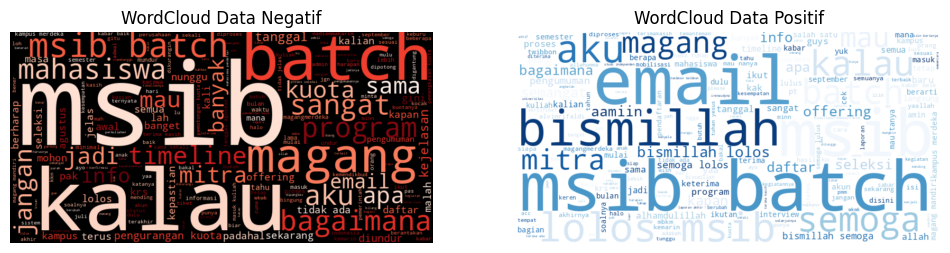

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter data negatif dan positif
negative_text = " ".join(df[df['label'] == -1]['komentar'].astype(str))
positive_text = " ".join(df[df['label'] == 1]['komentar'].astype(str))

# Buat WordCloud untuk data negatif
plt.figure(figsize=(12, 6))
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Data Negatif")

# Buat WordCloud untuk data positif
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(positive_text)
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Data Positif")

plt.show()

**Distribusi Data**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

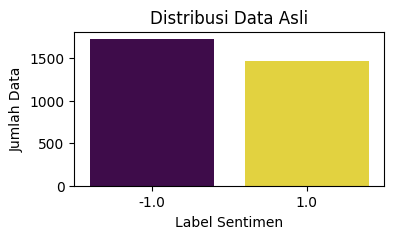

Jumlah Total Data: 3250
Jumlah Data Negatif: 1725
Jumlah Data Positif: 1469


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi data asli
plt.figure(figsize=(4, 2))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribusi Data Asli')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Data')
plt.show()

# Hitung jumlah seluruh data, jumlah data negatif dan positif
total_data = len(df)
jumlah_negatif = (df['label'] == -1.0).sum()
jumlah_positif = (df['label'] == 1.0).sum()

# Tampilkan hasil perhitungan
print("Jumlah Total Data:", total_data)
print("Jumlah Data Negatif:", jumlah_negatif)
print("Jumlah Data Positif:", jumlah_positif)

**Data Splitting**

Data Splitting merupakan teknik membagi data untuk data train dan data testing. Data akan dibagi dengan metode 80:10:10.

Pertama, data akan dibagi menjadi 80% untuk data train, selajut 20% akandibagi menjadi 10% untuk data test, dan 10% untuk data validasi.

In [ ]:
#Menghapus data kosong
df = df.dropna(subset=['label'])
df = df.dropna(subset=['komentar'])

# Tentukan variabel
X = df['komentar']  # komentar
y = df['label']     # label sentimen

# Langkah pertama: bagi data menjadi 80% untuk training dan 20% sisanya (untuk validation dan test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training set:", len(X_train))

# Langkah kedua: bagi 20% data menjadi 10% validation dan 10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print("Validation set:", len(X_val))
print("Test set:", len(X_test))


Training set: 2555
Validation set: 319
Test set: 320


**Pembobotan TF-IDF**

TF-IDF (term frequency- inverse document frequency) merupakan metode untuk menentukan bobot kata pada teks berdasarkan frekuensi kemunculan kata dan bobot invers dari frekuensi kemunculan kata-kata tersebut di seluruh kalimat.

TF = jumlah frekuensi term t/ jumlah term t dalam dokumen

IDF = Log (jumlah dokumen dalam korpus/ jumlah dokumen yang mengandung term t)

TF-IDF = TF * IDF

Implementasi rumus ini dalma kode pthon dapat diterapkan seperti kode di bawah, namun, kode ini tidak dijalakan ada program ini karena program ini menggunakan implementasi yang sudah diterapkan dalam library sk.learn

**Kode implementasi manual** *(tidak dijalankan)*

source code: https://github.com/Wittline/tf-idf/blob/main/code/TFIDF.py

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
import scipy.sparse as sp
from numpy.linalg import norm

class TFIDF(object):

    def __init__(self, corpus):
        self.corpus = corpus
        self.norm_corpus  = None

    def __normalize_corpus(self, d):
        stop_words = nltk.corpus.stopwords.words('english')
        d = re.sub(r'[^a-zA-Z0-9\s]', '', d, re.I|re.A)
        d = d.lower().strip()
        tks = nltk.word_tokenize(d)
        f_tks = [t for t in tks if t not in stop_words]
        return ' '.join(f_tks)

    def preprocessing_text(self):
        n_c = np.vectorize(self.__normalize_corpus)
        self.norm_corpus = n_c(self.corpus)

    def tf(self):
        words_array = [doc.split() for doc in self.norm_corpus]
        words = list(set([word for words in words_array for word in words]))
        features_dict = {w:0 for w in words}
        tf = []
        for doc in self.norm_corpus:
            bowf_doc = Counter(doc.split())
            all_f = Counter(features_dict)
            bowf_doc.update(all_f)
            tf.append(bowf_doc)
        return pd.DataFrame(tf)

    def df(self, tf):
        features_names = list(tf.columns)
        df = np.diff(sp.csc_matrix(tf, copy=True).indptr)
        df = 1 + df
        return df

    def idf(self, df):
        N = 1 + len(self.norm_corpus)
        idf = (1.0 + np.log(float(N) / df))
        idf_d = sp.spdiags(idf, diags= 0, m=len(df), n= len(df)).todense()
        return idf, idf_d

    def tfidf(self, tf, idf):
        tf = np.array(tf, dtype='float64')
        tfidf = tf * idf
        norms = norm(tfidf , axis=1)
        return (tfidf / norms[:,None])

**Implementasi mengunakan libraly sklearn**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import pandas as pd

# Inisialisasi TfidfVectorizer
tfidf = TfidfVectorizer(max_features=2500)  # membatasi jumlah kata yg paling banyak muncul

# Mengatasi nilai NaN dengan mengubahnya menjadi string kosong
X_train = X_train.fillna('')
X_val = X_val.fillna('')
X_test = X_test.fillna('')

# Fit dan transform data TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# Menampilkan bentuk matriks TF-IDF
print("TF-IDF Matrix Shape (Training):", X_train_tfidf.shape)
print("TF-IDF Matrix Shape (Validation):", X_val_tfidf.shape)
print("TF-IDF Matrix Shape (Test):", X_test_tfidf.shape)

# Preview beberapa nilai TF-IDF dalam bentuk DataFrame agar mudah dibaca
tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())
print(tfidf_df.head())

TF-IDF Matrix Shape (Training): (2555, 2500)
TF-IDF Matrix Shape (Validation): (319, 2500)
TF-IDF Matrix Shape (Test): (320, 2500)
    01   10  100   11  1131   12  12000   13   14   15  ...  yesus   yo  yok  \
0  0.0  0.0  0.0  0.0   0.0  0.0    0.0  0.0  0.0  0.0  ...    0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0   0.0  0.0    0.0  0.0  0.0  0.0  ...    0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0   0.0  0.0    0.0  0.0  0.0  0.0  ...    0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0   0.0  0.0    0.0  0.0  0.0  0.0  ...    0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0   0.0  0.0    0.0  0.0  0.0  0.0  ...    0.0  0.0  0.0   

   you  yth   yu  yuk  yukkk  zhaaaneys  zonasi  
0  0.0  0.0  0.0  0.0    0.0        0.0     0.0  
1  0.0  0.0  0.0  0.0    0.0        0.0     0.0  
2  0.0  0.0  0.0  0.0    0.0        0.0     0.0  
3  0.0  0.0  0.0  0.0    0.0        0.0     0.0  
4  0.0  0.0  0.0  0.0    0.0        0.0     0.0  

[5 rows x 2500 columns]


**TF-IDF Menggunakan SVM**

In [ ]:
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Baseline model**

Baseline model ini menggunakan kernel linear dengan parameter default (tanpa hyperparameter tuning) dan mengevaluasi kinerja pada data validasi serta data tes. Fungsi baseline di sini adalah memberikan gambaran awal tentang performa model dengan menggunakan pengaturan dasar, tanpa optimasi tambahan.

Validation Accuracy: 0.8056426332288401
Validation Classification Report
              precision    recall  f1-score   support

        -1.0       0.81      0.84      0.82       172
         1.0       0.81      0.76      0.78       147

    accuracy                           0.81       319
   macro avg       0.81      0.80      0.80       319
weighted avg       0.81      0.81      0.81       319

Validation Confusion Matrix:


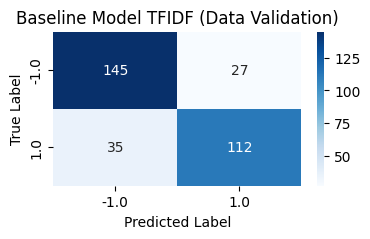


Test Accuracy: 0.80625
Test Classification Report
              precision    recall  f1-score   support

        -1.0       0.81      0.83      0.82       173
         1.0       0.80      0.78      0.79       147

    accuracy                           0.81       320
   macro avg       0.81      0.80      0.80       320
weighted avg       0.81      0.81      0.81       320

Test Confusion Matrix:


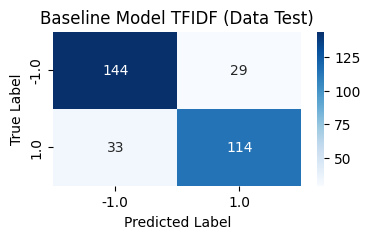

In [ ]:
# Inisialisasi dan latih model SVM Linear
svm_model_tfidf = SVC(kernel='linear', random_state=42)
svm_model_tfidf.fit(X_train_tfidf, y_train)

# Evaluasi model pada data validasi
y_val_pred = svm_model_tfidf.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report")
print (classification_report(y_val, y_val_pred))

# Confussion matrix validation set
confusion_val = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:")
# print(confusion_val)

# Visualize validation confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.title("Baseline Model TFIDF (Data Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi model pada data test
y_test_pred = svm_model_tfidf.predict(X_test_tfidf)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report")
print (classification_report(y_test, y_test_pred))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("Test Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Baseline Model TFIDF (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Hyperparameter Tuning**

Hyperparameter tuning adalah proses mencari nilai terbaik untuk parameter yang digunakan dalam membangun model. Ada beberapa parameter dalam SVM:

1. **C** : Nilai C memengaruhi seberapa besar margin (jarak antara hyperplane pemisah dengan support vectors) yang diinginkan oleh SVM. Jika nilai C tinggi, SVM akan mencoba untuk memisahkan kelas dengan margin sempit dan berupaya keras agar tidak ada data yang salah klasifikasi.
Sebaliknya, jika C rendah, model akan mengizinkan beberapa kesalahan dalam klasifikasi, dengan imbalan margin yang lebih besar.

2. **Kernel** : Fungsi yang digunakan untuk mengubah data ke dalam dimensi yang lebih tinggi agar dapat dipisahkan oleh hyperplane.
Contohnya, bayangkan kita punya data yang tersebar seperti lingkaran. Di dimensi dua, kita tidak bisa memisahkannya dengan garis lurus. Tapi dengan bantuan kernel, data tersebut dipindahkan ke dimensi yang lebih tinggi, di mana pola lingkaran bisa "datar" dan mudah dipisahkan oleh SVM.
Dalam model ini kernel yang digunakan adalah linear.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import time

# Definisikan parameter yang ingin di-tuning
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 200, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]}  # parameter regulasi

# Inisialisasi model SVM
svm = SVC(kernel='linear', random_state=42)

# Variabel untuk melacak model terbaik
best_model_svm_tfidf = None
best_param_svm_tfidf = None
best_score_svm_tfidf = 0

# List untuk menyimpan hasil evaluasi
results = []

# Latih model dengan tuning hyperparameter pada data training
for params in param_grid['C']:
    time_start = time.time()

    # Set parameter dan fit model
    svm_classifier = SVC(kernel='linear', C=params, random_state=42)
    svm_classifier.fit(X_train_tfidf, y_train)

    # Prediksi pada training dan validation set
    y_train_pred = svm_classifier.predict(X_train_tfidf)
    y_val_pred = svm_classifier.predict(X_val_tfidf)

    # Hitung akurasi
    score_train = accuracy_score(y_train, y_train_pred)
    score_val = accuracy_score(y_val, y_val_pred)

    # Hitung metrik lainnya dengan menangani zero_division
    precision_train = precision_score(y_train, y_train_pred, average='binary', zero_division=1)
    recall_train = recall_score(y_train, y_train_pred, average='binary', zero_division=1)
    f1_train = f1_score(y_train, y_train_pred, average='binary', zero_division=1)

    precision_val = precision_score(y_val, y_val_pred, average='binary', zero_division=1)
    recall_val = recall_score(y_val, y_val_pred, average='binary', zero_division=1)
    f1_val = f1_score(y_val, y_val_pred, average='binary', zero_division=1)

    # Matriks kebingungannya
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val = confusion_matrix(y_val, y_val_pred)

    # Simpan hasil evaluasi untuk tabel
    results.append([params, round(score_train, 4), round(precision_train, 4), round(recall_train, 4), round(f1_train, 4), cm_train,
                    round(score_val, 4), round(precision_val, 4), round(recall_val, 4), round(f1_val, 4), cm_val])

    # Hitung waktu komputasi
    time_stop = time.time()
    m, s = divmod(int(time_stop - time_start), 60)

    print(f"Parameter C: {params}, Training accuracy: {score_train:.4f}, Validation accuracy: {score_val:.4f}, Runtime: {m}m{s}s")

    # Simpan model terbaik berdasarkan akurasi pada validation set
    if score_val > best_score_svm_tfidf:
        best_param_svm_tfidf = params
        best_score_svm_tfidf = score_val
        best_model_svm_tfidf = svm_classifier

# Tampilkan model dan parameter terbaik
print(f"\nBest model: {best_model_svm_tfidf}")
print(f"Best parameters: {best_param_svm_tfidf}")
print(f"Best validation accuracy: {best_score_svm_tfidf:.4f}")

# Membuat DataFrame untuk menyimpan hasil evaluasi
df_results = pd.DataFrame(results, columns=["C", "Train Accuracy", "Train Precision", "Train Recall", "Train F1-Score", "Train Confusion Matrix",
                                            "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Confusion Matrix"])

# Simpan DataFrame ke file Excel dengan 4 angka dibelakang koma
df_results.to_excel('tfidf_results.xlsx', index=False)


Parameter C: 0.001, Training accuracy: 0.5401, Validation accuracy: 0.5392, Runtime: 0m0s
Parameter C: 0.01, Training accuracy: 0.5409, Validation accuracy: 0.5392, Runtime: 0m0s
Parameter C: 0.1, Training accuracy: 0.7374, Validation accuracy: 0.6897, Runtime: 0m0s
Parameter C: 1, Training accuracy: 0.9268, Validation accuracy: 0.8056, Runtime: 0m0s
Parameter C: 10, Training accuracy: 0.9722, Validation accuracy: 0.7994, Runtime: 0m0s
Parameter C: 100, Training accuracy: 0.9812, Validation accuracy: 0.7837, Runtime: 0m0s
Parameter C: 200, Training accuracy: 0.9816, Validation accuracy: 0.7868, Runtime: 0m0s
Parameter C: 300, Training accuracy: 0.9820, Validation accuracy: 0.7837, Runtime: 0m1s
Parameter C: 400, Training accuracy: 0.9820, Validation accuracy: 0.7837, Runtime: 0m0s
Parameter C: 500, Training accuracy: 0.9820, Validation accuracy: 0.7837, Runtime: 0m0s
Parameter C: 550, Training accuracy: 0.9820, Validation accuracy: 0.7837, Runtime: 0m1s
Parameter C: 600, Training accur

Test Accuracy with best model: 0.80625
Test Classification Report with best model:
               precision    recall  f1-score   support

        -1.0     0.8136    0.8324    0.8229       173
         1.0     0.7972    0.7755    0.7862       147

    accuracy                         0.8063       320
   macro avg     0.8054    0.8039    0.8045       320
weighted avg     0.8060    0.8063    0.8060       320


Test Confusion Matrix:


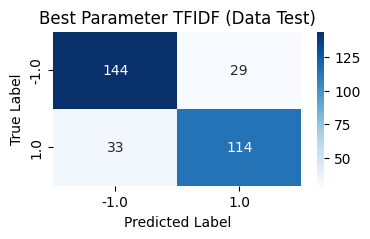

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluasi model terbaik pada data tes
y_test_pred = best_model_svm_tfidf.predict(X_test_tfidf)
print("Test Accuracy with best model:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report with best model:\n", classification_report(y_test, y_test_pred, digits=4))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("\nTest Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Best Parameter TFIDF (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Pembobotan Word2Vec**

Word2Vec akan merepresentasikan kata menjadi bentuk vector dengan dimensi yang ditentukan. Word2Vec terbagi menjadi 2 jenis yaitu, skip-gram yang akan menghasilkan representasi vektor kata berdasarkan hubungan antar target dan kontesnya. Sedangkan Continous Bag of Words (CBOW) akan memprediksi kata target berdasarkan kata konteks yang mengelilinginya.

Kalimat “aku sangat cinta negara Indonesia”. Pada model CBOW, kata “cinta” akan digunakan di input layer untuk memprediksi kata “aku” sangat”, “negara” “Indonesia”. Sedangkan, pada model Skipgram, kata “aku” sangat”, “negara” “Indonesia” digunakan di input layer untuk memprediksi kata “cinta”

**CBOW (Continous Bag of Words)**

In [ ]:
!pip install gensim

from gensim.models import Word2Vec

In [ ]:
# Contoh kode tokenisasi sederhana dengan split
X_train_tokens = [text.split() for text in X_train]

# Membuat model Word2Vec dengan pendekatan CBOW (sg=0)
# CBOW akan menjadikan kata ditengah untuk memprediksi kata disekitarnya
#window = 2 adalah jarak sampai mana kata sekitarnya akan diprediksi
# min_count=1 artinya anya kata yang muncul setidaknya dua kali yang akan divektorkan
# workers=4 adalah jumlah core CPU yang digunakan untuk mempercepat proses
model_cbow = Word2Vec(sentences=X_train_tokens, vector_size=150, window=3, min_count=2, sg=0, workers=4)

# Menampilkan vektor dari kata tertentu (misalnya 'program')
print(model_cbow.wv['program'])

# Melihat 5 kata yg mirip
similar_words = model_cbow.wv.most_similar('program', topn=5)
print("5 kata yang mirip:")
print(similar_words)

[ 8.66240785e-02  2.09991485e-02 -6.09592795e-02 -1.68404430e-02
  7.83109479e-03 -5.24301678e-02 -2.48285271e-02  1.83968350e-01
 -3.01690469e-03  1.19481109e-01  3.21398191e-02 -9.38724820e-03
 -1.69889361e-01  1.46201089e-01 -1.63904697e-01 -9.56242234e-02
  1.14542238e-01  2.20899452e-02  3.03453133e-02  1.63277566e-01
 -1.40522718e-01 -5.42710908e-02  9.97147337e-02  1.33905232e-01
  1.03883125e-01  2.54697688e-02 -1.20069645e-01 -1.60762548e-01
 -7.09795430e-02 -1.06909022e-01  3.34224589e-02  5.02379388e-02
 -1.04222991e-01 -9.62649286e-02 -9.31839570e-02  8.16727653e-02
  2.26422414e-01  4.04821932e-02  7.08687827e-02 -1.11731775e-01
 -4.33496013e-02 -2.83867633e-03 -1.63507432e-01 -9.46929455e-02
  1.83534697e-01  1.16853556e-02  7.42775435e-03 -4.87777218e-02
  3.42132784e-02  6.76252693e-02 -9.86671522e-02  6.94712922e-02
 -7.63878226e-02 -1.11015933e-03 -5.46669820e-03  4.70641330e-02
  4.46050577e-02  1.70055293e-02  4.65920046e-02 -3.47034000e-02
 -2.60411780e-02 -2.10967

In [ ]:
import numpy as np

# Fungsi untuk mengonversi kalimat menjadi vektor dengan model Word2Vec
def get_average_word2vec(tokens_list, model, vector_size=150):
    # Menyimpan vektor untuk setiap kata
    vecs = []

    # Mengambil vektor untuk setiap kata dalam kalimat
    for word in tokens_list:
        if word in model.wv:
            vecs.append(model.wv[word])
        else:
            # Jika kata tidak ada dalam model, kita beri vektor nol (misalnya untuk kata yang tidak dikenal)
            vecs.append(np.zeros(vector_size))

    # Mengambil rata-rata vektor kata
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        # Jika tidak ada kata yang ditemukan, kembalikan vektor nol
        return np.zeros(vector_size)

# Mengonversi X_train, X_val, dan X_test menjadi vektor dengan Word2Vec
X_train_cbow = [get_average_word2vec(text.split(), model_cbow) for text in X_train]
X_val_cbow = [get_average_word2vec(text.split(), model_cbow) for text in X_val]
X_test_cbow = [get_average_word2vec(text.split(), model_cbow) for text in X_test]

# Konversi hasilnya menjadi array NumPy untuk pelatihan model SVM
X_train_cbow = np.array(X_train_cbow)
X_val_cbow = np.array(X_val_cbow)
X_test_cbow = np.array(X_test_cbow)

In [ ]:
# Contoh melihat vektor untuk komentar pertama di data training
print("Komentar:", X_train[0])
print("Vektor hasil pembobotan:", X_train_cbow[0])

Komentar: minn tiket dapett
Vektor hasil pembobotan: [ 6.54885056e-03 -8.41676258e-04 -3.67901471e-03 -1.48900792e-03
  1.60820484e-03 -3.68384998e-03 -2.34609512e-03  1.07337832e-02
  7.36375444e-04  8.38177642e-03  2.42743385e-04  7.26705883e-04
 -1.25026575e-02  1.22228486e-02 -1.28740233e-02 -7.58907674e-03
  8.03982199e-03  2.58092876e-03  3.50195281e-03  7.73503734e-03
 -9.74131366e-03 -6.27899077e-04  5.66615560e-03  1.17774744e-02
  6.22364571e-03  2.30953814e-03 -6.48471508e-03 -1.04116453e-02
 -3.54266576e-03 -5.91962725e-03  3.91072799e-03  3.02646978e-03
 -7.48721352e-03 -6.25221618e-03 -7.65408771e-03  6.61828807e-03
  1.73140347e-02  2.80114561e-03  4.57054984e-03 -5.75089520e-03
 -1.38952243e-03 -1.85978378e-04 -1.03285125e-02 -5.51379312e-03
  1.38583792e-02  2.56840282e-03  1.66895860e-03 -2.87132668e-03
  3.78692970e-03  4.45507474e-03 -5.78300226e-03  6.05587764e-03
 -3.69114249e-03 -2.38768570e-03  5.21829363e-04  5.15205730e-03
  2.90282415e-03  1.48957148e-03  2.3

**Baseline model**

Validation Accuracy: 0.6175548589341693
Validation Classification Report
              precision    recall  f1-score   support

        -1.0       0.63      0.72      0.67       172
         1.0       0.60      0.50      0.54       147

    accuracy                           0.62       319
   macro avg       0.61      0.61      0.61       319
weighted avg       0.62      0.62      0.61       319

Validation Confusion Matrix:


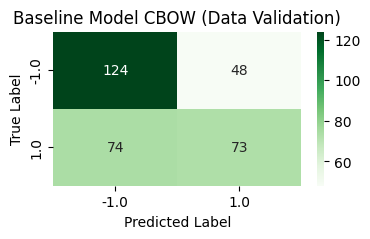


Test Accuracy: 0.603125
Test Classification Report
              precision    recall  f1-score   support

        -1.0       0.62      0.70      0.66       173
         1.0       0.58      0.49      0.53       147

    accuracy                           0.60       320
   macro avg       0.60      0.59      0.59       320
weighted avg       0.60      0.60      0.60       320

Test Confusion Matrix:


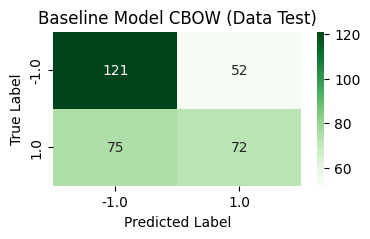

In [ ]:
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi dan latih model SVM Linear
svm_model_cbow = SVC(kernel='linear', random_state=42)
svm_model_cbow.fit(X_train_cbow, y_train)

# Evaluasi model pada data validasi
y_val_pred = svm_model_cbow.predict(X_val_cbow)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report")
print (classification_report(y_val, y_val_pred))

# Confussion matrix validation set
confusion_val = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:")
# print(confusion_val)

# Visualize validation confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.title("Baseline Model CBOW (Data Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi model pada data test
y_test_pred = svm_model_cbow.predict(X_test_cbow)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report")
print (classification_report(y_test, y_test_pred))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("Test Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Baseline Model CBOW (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Hyperparameter Tuning**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import time

# Definisikan parameter yang ingin di-tuning
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 200, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]}  # parameter regulasi

# Inisialisasi model SVM
svm = SVC(kernel='linear', random_state=42)

# Variabel untuk melacak model terbaik
best_model_svm_cbow = None
best_param_svm_cbow = None
best_score_svm_cbow = 0

# List untuk menyimpan hasil evaluasi
results = []

# Latih model dengan tuning hyperparameter pada data training
for params in param_grid['C']:
    time_start = time.time()

    # Set parameter dan fit model
    svm_classifier = SVC(kernel='linear', C=params, random_state=42)
    svm_classifier.fit(X_train_cbow, y_train)

    # Prediksi pada training dan validation set
    y_train_pred = svm_classifier.predict(X_train_cbow)
    y_val_pred = svm_classifier.predict(X_val_cbow)

    # Hitung akurasi
    score_train = accuracy_score(y_train, y_train_pred)
    score_val = accuracy_score(y_val, y_val_pred)

    # Hitung metrik lainnya dengan menangani zero_division
    precision_train = precision_score(y_train, y_train_pred, average='binary', zero_division=1)
    recall_train = recall_score(y_train, y_train_pred, average='binary', zero_division=1)
    f1_train = f1_score(y_train, y_train_pred, average='binary', zero_division=1)

    precision_val = precision_score(y_val, y_val_pred, average='binary', zero_division=1)
    recall_val = recall_score(y_val, y_val_pred, average='binary', zero_division=1)
    f1_val = f1_score(y_val, y_val_pred, average='binary', zero_division=1)

    # Matriks kebingungannya
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val = confusion_matrix(y_val, y_val_pred)

    # Simpan hasil evaluasi untuk tabel
    results.append([params, round(score_train, 4), round(precision_train, 4), round(recall_train, 4), round(f1_train, 4), cm_train,
                    round(score_val, 4), round(precision_val, 4), round(recall_val, 4), round(f1_val, 4), cm_val])

    # Hitung waktu komputasi
    time_stop = time.time()
    m, s = divmod(int(time_stop - time_start), 60)

    print(f"Parameter C: {params}, Training accuracy: {score_train:.4f}, Validation accuracy: {score_val:.4f}, Runtime: {m}m{s}s")

    # Simpan model terbaik berdasarkan akurasi pada validation set
    if score_val > best_score_svm_cbow:
        best_param_svm_cbow = params
        best_score_svm_cbow = score_val
        best_model_svm_cbow = svm_classifier

# Tampilkan model dan parameter terbaik
print(f"\nBest model: {best_model_svm_cbow}")
print(f"Best parameters: {best_param_svm_cbow}")
print(f"Best validation accuracy: {best_score_svm_cbow:.4f}")

# Membuat DataFrame untuk menyimpan hasil evaluasi
df_results = pd.DataFrame(results, columns=["C", "Train Accuracy", "Train Precision", "Train Recall", "Train F1-Score", "Train Confusion Matrix",
                                            "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Confusion Matrix"])

# Simpan DataFrame ke file Excel dengan 4 angka dibelakang koma
df_results.to_excel('cbow_results.xlsx', index=False)


Parameter C: 0.001, Training accuracy: 0.5401, Validation accuracy: 0.5392, Runtime: 0m1s
Parameter C: 0.01, Training accuracy: 0.5401, Validation accuracy: 0.5392, Runtime: 0m1s
Parameter C: 0.1, Training accuracy: 0.6153, Validation accuracy: 0.6207, Runtime: 0m0s
Parameter C: 1, Training accuracy: 0.6196, Validation accuracy: 0.6176, Runtime: 0m1s
Parameter C: 10, Training accuracy: 0.6423, Validation accuracy: 0.6332, Runtime: 0m1s
Parameter C: 100, Training accuracy: 0.7155, Validation accuracy: 0.6865, Runtime: 0m1s
Parameter C: 200, Training accuracy: 0.7429, Validation accuracy: 0.7210, Runtime: 0m1s
Parameter C: 300, Training accuracy: 0.7495, Validation accuracy: 0.7210, Runtime: 0m1s
Parameter C: 400, Training accuracy: 0.7523, Validation accuracy: 0.7273, Runtime: 0m1s
Parameter C: 500, Training accuracy: 0.7585, Validation accuracy: 0.7273, Runtime: 0m1s
Parameter C: 550, Training accuracy: 0.7605, Validation accuracy: 0.7398, Runtime: 0m2s
Parameter C: 600, Training accur

Test Accuracy with best model: 0.69375
Test Classification Report with best model:
               precision    recall  f1-score   support

        -1.0     0.7049    0.7457    0.7247       173
         1.0     0.6788    0.6327    0.6549       147

    accuracy                         0.6937       320
   macro avg     0.6919    0.6892    0.6898       320
weighted avg     0.6929    0.6937    0.6927       320


Test Confusion Matrix:


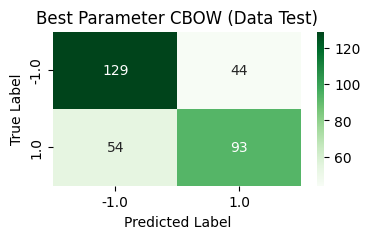

In [ ]:
# Evaluasi model terbaik pada data tes
y_test_pred = best_model_svm_cbow.predict(X_test_cbow)
print("Test Accuracy with best model:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report with best model:\n", classification_report(y_test, y_test_pred,  digits=4))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("\nTest Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Best Parameter CBOW (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Word2vec Skipgram**

In [ ]:
# Tokenisasi sederhana dengan split
X_train_tokens = [text.split() for text in X_train]

# Membuat model Word2Vec dengan pendekatan Skipgram (sg=1)
model_skipgram = Word2Vec(sentences=X_train_tokens, vector_size=150, window=3, min_count=2, sg=1, workers=4)

# Menampilkan vektor dari kata tertentu (misalnya 'program')
print(model_skipgram.wv['program'])

# Melihat 5 kata yg mirip
similar_words = model_skipgram.wv.most_similar('program', topn=5)
print("5 kata yang mirip:")
print(similar_words)

[ 0.06702579  0.01885384 -0.1186787   0.00960444  0.03581739 -0.05156319
  0.01852313  0.23411505 -0.05186504  0.13760261 -0.02672353 -0.01059184
 -0.21324691  0.14334103 -0.1373102  -0.08537465  0.17080788  0.01628719
  0.05751761  0.160354   -0.17580295 -0.06738283  0.14167792  0.20102727
  0.17166556  0.01634169 -0.15143827 -0.23736522 -0.12563731 -0.114028
  0.01145959  0.14029808 -0.12985028 -0.11205603 -0.14207932  0.08394811
  0.26809278  0.08161556  0.09248445 -0.14870301 -0.07437146 -0.0112404
 -0.1775448  -0.1482793   0.23623271  0.0829076  -0.02541089 -0.04545308
  0.0264957   0.1017179  -0.0861256   0.08536205 -0.08004925  0.03588944
 -0.00790879  0.0442922   0.05688811 -0.00513575  0.04956698 -0.03780676
  0.024314   -0.21613616 -0.09027354 -0.00727841  0.09779266 -0.05369776
 -0.03866172 -0.26717296 -0.27718362 -0.07846534  0.1307128   0.17583379
  0.03939077 -0.28403124 -0.00129473 -0.02939494 -0.11576094 -0.02215157
 -0.16336901  0.20191057  0.08420824 -0.14890835 -0.01

In [ ]:
import numpy as np

# Fungsi untuk mengonversi kalimat menjadi vektor dengan model Word2Vec
def get_average_word2vec(tokens_list, model, vector_size=150):
    # Menyimpan vektor untuk setiap kata
    vecs = []

    # Mengambil vektor untuk setiap kata dalam kalimat
    for word in tokens_list:
        if word in model.wv:
            vecs.append(model.wv[word])
        else:
            # Jika kata tidak ada dalam model, kita beri vektor nol (misalnya untuk kata yang tidak dikenal)
            vecs.append(np.zeros(vector_size))

    # Mengambil rata-rata vektor kata
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        # Jika tidak ada kata yang ditemukan, kembalikan vektor nol
        return np.zeros(vector_size)

# Mengonversi X_train, X_val, dan X_test menjadi vektor dengan Word2Vec
X_train_skipgram = [get_average_word2vec(text.split(), model_skipgram) for text in X_train]
X_val_skipgram = [get_average_word2vec(text.split(), model_skipgram) for text in X_val]
X_test_skipgram = [get_average_word2vec(text.split(), model_skipgram) for text in X_test]

# Konversi hasilnya menjadi array NumPy untuk pelatihan model SVM
X_train_skipgram = np.array(X_train_skipgram)
X_val_skipgram = np.array(X_val_skipgram)
X_test_skipgram = np.array(X_test_skipgram)

In [ ]:
# Contoh melihat vektor untuk komentar pertama di data training
print("Komentar:", X_train[0])
print("Vektor hasil pembobotan:", X_train_skipgram[0])

Komentar: minn tiket dapett
Vektor hasil pembobotan: [ 1.60014899e-02  1.78462688e-03 -2.80439567e-02  7.85919232e-04
  1.00300383e-02 -1.29189784e-02  3.74814980e-03  5.19135112e-02
 -1.10473874e-02  3.14083816e-02 -8.76243766e-03 -2.17663937e-03
 -5.08568149e-02  3.48650213e-02 -3.31155535e-02 -2.07175428e-02
  3.83956559e-02  6.00936380e-03  1.55117583e-02  3.36391428e-02
 -4.06170636e-02 -1.17821704e-02  3.09977900e-02  4.90269396e-02
  3.90026352e-02  3.26181115e-03 -3.25387709e-02 -5.52971356e-02
 -2.85280056e-02 -2.54185945e-02  3.62984077e-03  3.26910386e-02
 -3.15505469e-02 -2.46659545e-02 -3.39874143e-02  2.13095505e-02
  6.45440992e-02  2.04427404e-02  2.13048227e-02 -3.16508422e-02
 -1.52513728e-02 -2.87581449e-03 -4.10209699e-02 -3.31839213e-02
  5.76027106e-02  2.17762196e-02 -4.35494278e-03 -9.62295588e-03
  8.92777080e-03  2.40222469e-02 -2.05218984e-02  2.06291359e-02
 -1.60063935e-02  5.49003314e-03 -3.89988674e-04  1.37574703e-02
  1.26268528e-02 -1.13013145e-03  1.1

**Baseline Model**

Validation Accuracy: 0.5956112852664577
Validation Classification Report
              precision    recall  f1-score   support

        -1.0       0.59      0.81      0.68       172
         1.0       0.61      0.35      0.44       147

    accuracy                           0.60       319
   macro avg       0.60      0.58      0.56       319
weighted avg       0.60      0.60      0.57       319

Validation Confusion Matrix:


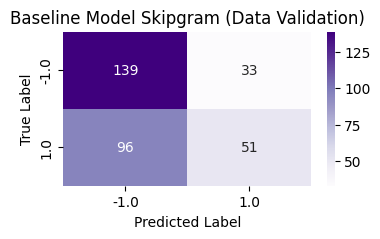


Test Accuracy: 0.615625
Test Classification Report
              precision    recall  f1-score   support

        -1.0       0.60      0.84      0.70       173
         1.0       0.65      0.35      0.46       147

    accuracy                           0.62       320
   macro avg       0.63      0.60      0.58       320
weighted avg       0.63      0.62      0.59       320

Test Confusion Matrix:


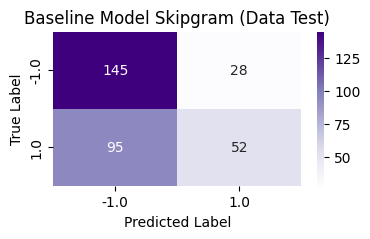

In [ ]:
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi dan latih model SVM Linear
svm_model_skipgram = SVC(kernel='linear', random_state=42)
svm_model_skipgram.fit(X_train_skipgram, y_train)

# Evaluasi model pada data validasi
y_val_pred = svm_model_skipgram.predict(X_val_skipgram)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report")
print (classification_report(y_val, y_val_pred))

# Confussion matrix validation set
confusion_val = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:")
# print(confusion_val)

# Visualize validation confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_val, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.title("Baseline Model Skipgram (Data Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi model pada data test
y_test_pred = svm_model_skipgram.predict(X_test_skipgram)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report")
print (classification_report(y_test, y_test_pred))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("Test Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Baseline Model Skipgram (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Hyperparameter Tuning**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import time

# Definisikan parameter yang ingin di-tuning
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 200, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]}  # parameter regulasi

# Inisialisasi model SVM
svm = SVC(kernel='linear', random_state=42)

# Variabel untuk melacak model terbaik
best_model_svm_skipgram = None
best_param_svm_skipgram = None
best_score_svm_skipgram = 0

# List untuk menyimpan hasil evaluasi
results = []

# Latih model dengan tuning hyperparameter pada data training
for params in param_grid['C']:
    time_start = time.time()

    # Set parameter dan fit model
    svm_classifier = SVC(kernel='linear', C=params, random_state=42)
    svm_classifier.fit(X_train_skipgram, y_train)

    # Prediksi pada training dan validation set
    y_train_pred = svm_classifier.predict(X_train_skipgram)
    y_val_pred = svm_classifier.predict(X_val_skipgram)

    # Hitung akurasi
    score_train = accuracy_score(y_train, y_train_pred)
    score_val = accuracy_score(y_val, y_val_pred)

    # Hitung metrik lainnya dengan menangani zero_division
    precision_train = precision_score(y_train, y_train_pred, average='binary', zero_division=1)
    recall_train = recall_score(y_train, y_train_pred, average='binary', zero_division=1)
    f1_train = f1_score(y_train, y_train_pred, average='binary', zero_division=1)

    precision_val = precision_score(y_val, y_val_pred, average='binary', zero_division=1)
    recall_val = recall_score(y_val, y_val_pred, average='binary', zero_division=1)
    f1_val = f1_score(y_val, y_val_pred, average='binary', zero_division=1)

    # Matriks kebingungannya
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val = confusion_matrix(y_val, y_val_pred)

    # Simpan hasil evaluasi untuk tabel
    results.append([params, round(score_train, 4), round(precision_train, 4), round(recall_train, 4), round(f1_train, 4), cm_train,
                    round(score_val, 4), round(precision_val, 4), round(recall_val, 4), round(f1_val, 4), cm_val])

    # Hitung waktu komputasi
    time_stop = time.time()
    m, s = divmod(int(time_stop - time_start), 60)

    print(f"Parameter C: {params}, Training accuracy: {score_train:.4f}, Validation accuracy: {score_val:.4f}, Runtime: {m}m{s}s")

    # Simpan model terbaik berdasarkan akurasi pada validation set
    if score_val > best_score_svm_skipgram:
        best_param_svm_skipgram = params
        best_score_svm_skipgram = score_val
        best_model_svm_skipgram = svm_classifier

# Tampilkan model dan parameter terbaik
print(f"\nBest model: {best_model_svm_skipgram}")
print(f"Best parameters: {best_param_svm_skipgram}")
print(f"Best validation accuracy: {best_score_svm_skipgram:.4f}")

# Membuat DataFrame untuk menyimpan hasil evaluasi
df_results = pd.DataFrame(results, columns=["C", "Train Accuracy", "Train Precision", "Train Recall", "Train F1-Score", "Train Confusion Matrix",
                                            "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Confusion Matrix"])

# Simpan DataFrame ke file Excel dengan 4 angka dibelakang koma
df_results.to_excel('skipgram_results.xlsx', index=False)


Parameter C: 0.001, Training accuracy: 0.5401, Validation accuracy: 0.5392, Runtime: 0m1s
Parameter C: 0.01, Training accuracy: 0.6012, Validation accuracy: 0.5893, Runtime: 0m1s
Parameter C: 0.1, Training accuracy: 0.6047, Validation accuracy: 0.5862, Runtime: 0m0s
Parameter C: 1, Training accuracy: 0.6074, Validation accuracy: 0.5956, Runtime: 0m0s
Parameter C: 10, Training accuracy: 0.6798, Validation accuracy: 0.6646, Runtime: 0m0s
Parameter C: 100, Training accuracy: 0.7374, Validation accuracy: 0.7116, Runtime: 0m1s
Parameter C: 200, Training accuracy: 0.7468, Validation accuracy: 0.7147, Runtime: 0m1s
Parameter C: 300, Training accuracy: 0.7554, Validation accuracy: 0.7273, Runtime: 0m1s
Parameter C: 400, Training accuracy: 0.7581, Validation accuracy: 0.7398, Runtime: 0m2s
Parameter C: 500, Training accuracy: 0.7613, Validation accuracy: 0.7524, Runtime: 0m2s
Parameter C: 550, Training accuracy: 0.7624, Validation accuracy: 0.7492, Runtime: 0m1s
Parameter C: 600, Training accur

Test Accuracy with best model: 0.71875
Test Classification Report with best model:
               precision    recall  f1-score   support

        -1.0     0.7150    0.7977    0.7541       173
         1.0     0.7244    0.6259    0.6715       147

    accuracy                         0.7188       320
   macro avg     0.7197    0.7118    0.7128       320
weighted avg     0.7193    0.7188    0.7162       320


Test Confusion Matrix:


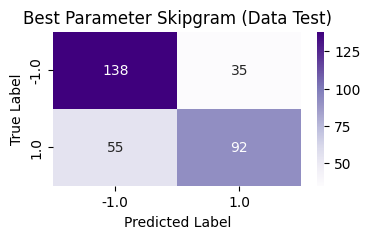

In [ ]:
# Evaluasi model terbaik pada data tes
y_test_pred = best_model_svm_skipgram.predict(X_test_skipgram)
print("Test Accuracy with best model:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report with best model:\n", classification_report(y_test, y_test_pred, digits=4))

# Confusion matrix untuk data tes
confusion_test = confusion_matrix(y_test, y_test_pred)
print("\nTest Confusion Matrix:")
# print(confusion_test)

# Visualize test confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(confusion_test, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Best Parameter Skipgram (Data Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()